# 英语→西班牙语 Transformer 翻译模型复现
复现 [PaddlePaddle 官方教程](https://www.paddlepaddle.org.cn/documentation/docs/zh/practices/nlp/transformer_in_English-to-Spanish.html)，
加载已训练好的权重，在整个测试集上计算 BLEU。

In [1]:
import paddle
import paddlenlp
from paddle.io import Dataset
from paddlenlp.data import Vocab
from paddlenlp.metrics import BLEU
import numpy as np
import string
import random
import matplotlib.pyplot as plt
from functools import partial
from collections import Counter

print(paddle.__version__)

c:\Users\zetad\anaconda3\envs\es\lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
c:\Users\zetad\anaconda3\envs\es\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\zetad\anaconda3\envs\es\lib\site-packages\_distutils_hack\__init__.py:30: UserWarning: Setuptools is replacing distutils. Support for replacing an already imported distutils is deprecated. In the future, this condition will fail. Register concerns at https://github.com/pypa/setuptools/issues/new?template=distutils-deprecation.yml
  warnings.warn(
c:\Users\zetad\anaconda3\envs\es\lib\site-packages\r

3.3.0


In [2]:
text_file='spa.txt' 

In [3]:
with open(text_file, encoding='utf-8') as f:
    lines = f.read().split("\n")[:-1]
text_pairs = []
for line in lines:
    eng, spa = line.split("\t")
    spa = "[start] " + spa + " [end]"
    text_pairs.append((eng, spa))

In [4]:
random.shuffle(text_pairs)
num_val_samples = int(0.1 * len(text_pairs))
num_train_samples = len(text_pairs) - 2 * num_val_samples
train_pairs = text_pairs[:num_train_samples]
val_pairs = text_pairs[num_train_samples : num_train_samples + num_val_samples]
test_pairs = text_pairs[num_train_samples + num_val_samples :]

print(f"{len(text_pairs)} total pairs")
print(f"{len(train_pairs)} training pairs")
print(f"{len(val_pairs)} validation pairs")
print(f"{len(test_pairs)} test pairs")

118964 total pairs
95172 training pairs
11896 validation pairs
11896 test pairs


In [5]:
train_eng_texts = [pair[0] for pair in train_pairs]
train_spa_texts = [pair[1] for pair in train_pairs]

val_eng_texts = [pair[0] for pair in val_pairs]
val_spa_texts = [pair[1] for pair in val_pairs]

test_eng_texts = [pair[0] for pair in test_pairs]
test_spa_texts = [pair[1] for pair in test_pairs]

In [6]:
def pre_process(datas, save_punctuation=False):
    dataset = []
    # 定义标点符号集合

    strip_chars = string.punctuation + "¿¡"
    strip_chars = strip_chars.replace("[", "")
    strip_chars = strip_chars.replace("]", "")

    for i in range(len(datas)):
        lowercase = datas[i].lower()  # 全部转为小写

        out = ""
        if save_punctuation:
            # 在标点符号之前加空格，需注意有特殊情况
            for low in lowercase:
                if low in strip_chars:
                    if (
                        low == "¿" or low == "¡"
                    ):  # 分别表示西班牙语的反问号、反叹号
                        out += low + " "
                    else:
                        out += " " + low
                else:
                    out += low
        else:
            # 也可以选择删除除所有的标点
            for low in lowercase:
                if low not in strip_chars:
                    out += low

        dataset.append(out)
    return dataset

In [7]:
train_eng_texts_pre = pre_process(train_eng_texts)
train_spa_texts_pre = pre_process(train_spa_texts)

val_eng_texts_pre = pre_process(val_eng_texts)
val_spa_texts_pre = pre_process(val_spa_texts)

test_eng_texts_pre = pre_process(test_eng_texts)
test_spa_texts_pre = pre_process(test_spa_texts)

print("预处理结果展示：")
print("英语：标准化处理之前：", train_eng_texts[0])
print("英语：标准化处理之后：", train_eng_texts_pre[0])

print("西班牙语：标准化处理之前：", train_spa_texts[0])
print("西班牙语：标准化处理之后：", train_spa_texts_pre[0])

预处理结果展示：
英语：标准化处理之前： The dancer's graceful action charmed the audience.
英语：标准化处理之后： the dancers graceful action charmed the audience
西班牙语：标准化处理之前： [start] La actuación grácil del bailarín hechizó a la audiencia. [end]
西班牙语：标准化处理之后： [start] la actuación grácil del bailarín hechizó a la audiencia [end]


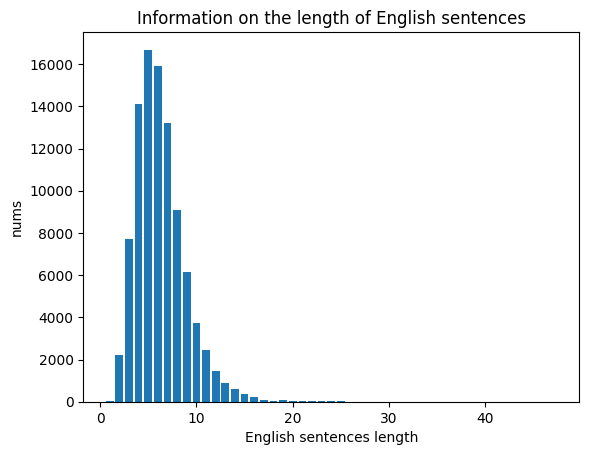

In [8]:
dicta = dict()
for text in train_eng_texts_pre:
    lent = len(text.split())
    if lent in dicta.keys():
        dicta[lent] += 1
    else:
        dicta[lent] = 1
lita = sorted(dicta.items(), key=lambda x: x[0], reverse=True)

x = [l[0] for l in lita]
y = [l[1] for l in lita]
plt.bar(x, y)
plt.xlabel("English sentences length")
plt.ylabel("nums")
plt.title("Information on the length of English sentences")
plt.show()

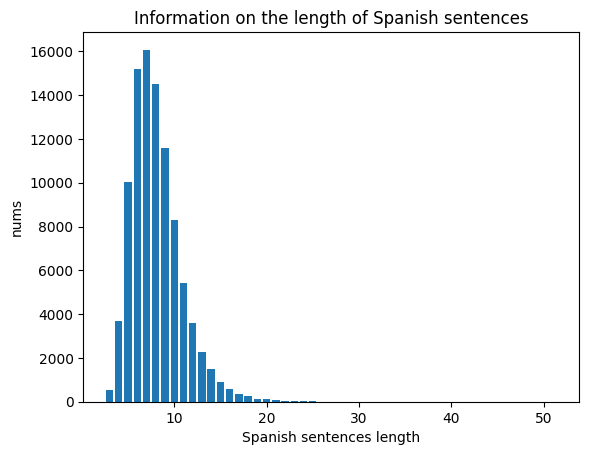

In [9]:
dicta = dict()
for text in train_spa_texts_pre:
    lent = len(text.split())
    if lent in dicta.keys():
        dicta[lent] += 1
    else:
        dicta[lent] = 1
lita = sorted(dicta.items(), key=lambda x: x[0], reverse=True)

x = [l[0] for l in lita]
y = [l[1] for l in lita]
plt.bar(x, y)
plt.xlabel("Spanish sentences length")
plt.ylabel("nums")
plt.title("Information on the length of Spanish sentences")
plt.show()

In [10]:
def build_cropus(data):
    crpous = []
    for i in range(len(data)):
        cr = data[i].strip().lower()
        cr = cr.split()
        crpous.extend(cr)
    return crpous

In [11]:
eng_crpous = build_cropus(train_eng_texts_pre)
spa_crpous = build_cropus(train_spa_texts_pre)

print(eng_crpous[:3])
print(spa_crpous[:3])

['the', 'dancers', 'graceful']
['[start]', 'la', 'actuación']


In [12]:
def build_dict(corpus, vocab_size):
    # 1.首先统计每个不同词的频率（出现的次数），使用一个词典记录
    word_freq_dict = dict()
    for word in corpus:
        if word not in word_freq_dict:
            word_freq_dict[word] = 0
        word_freq_dict[word] += 1

    # 2.将词典中的词，按照出现次数排序，出现次数越高，排序越靠前
    word_freq_dict = sorted(
        word_freq_dict.items(), key=lambda x: x[1], reverse=True
    )

    # 3.构造2个不同的词典
    # 每个词到id的映射关系：word2id_dict
    # 每个id到词的映射关系：id2word_dict
    word2id_dict = {"<pad>": 0, "<unk>": 1}
    id2word_dict = {0: "<pad>", 1: "<unk>"}

    # 4.按照频率，从高到低，开始遍历每个单词，并为这个单词构造一个独一无二的id
    i = 2
    for word, freq in word_freq_dict:
        if i < vocab_size:
            word2id_dict[word] = i
            id2word_dict[i] = word
            i += 1
        else:  # 超过指定的词汇量，指向<unk>
            word2id_dict[word] = 1
    return word2id_dict, id2word_dict

In [13]:
vocab_size = 25000  # 共享词汇量上限
eng2id_dict, id2eng_dict = build_dict(eng_crpous, vocab_size)
spa2id_dict, id2spa_dict = build_dict(spa_crpous, vocab_size)

print(
    "我们设置的英语总词汇上限为：",
    vocab_size,
    "\t总的英语词汇量为：",
    len(eng2id_dict),
    "\t我们实际使用的英语词汇量为",
    len(id2eng_dict),
)
print(
    "我们设置的西班牙语总词汇上限为：",
    vocab_size,
    "\t总的西班牙语词汇量为：",
    len(spa2id_dict),
    "\t我们实际使用的西班牙语词汇量为",
    len(id2spa_dict),
)

我们设置的英语总词汇上限为： 25000 	总的英语词汇量为： 12625 	我们实际使用的英语词汇量为 12625
我们设置的西班牙语总词汇上限为： 25000 	总的西班牙语词汇量为： 23831 	我们实际使用的西班牙语词汇量为 23831


In [14]:
def build_tensor(data, dicta, maxlen):
    tensor = []
    for i in range(len(data)):
        subtensor = []
        lista = data[i].split()
        for j in range(len(lista)):
            index = dicta.get(lista[j])
            # 对于训练解和测试集，可能会出现未在词表中的词汇，此时index会返回None,此时我们指定index=1,即指向<unk>
            if index == None:
                index = 1
            subtensor.append(index)

        if len(subtensor) < maxlen:
            # 0是我们进行padding的向量值
            subtensor += [0] * (maxlen - len(subtensor))
        else:
            subtensor = subtensor[:maxlen]

        tensor.append(subtensor)
    return np.array(tensor)

In [15]:
sequence_length = (
    20  # 语句长度我们统一设置为20，可以依据3.5小结的统计信息分开设置
)

train_eng_tensor = build_tensor(
    train_eng_texts_pre, eng2id_dict, sequence_length
)
val_eng_tensor = build_tensor(val_eng_texts_pre, eng2id_dict, sequence_length)
test_eng_tensor = build_tensor(test_eng_texts_pre, eng2id_dict, sequence_length)

train_spa_tensor = build_tensor(
    train_spa_texts_pre, spa2id_dict, sequence_length
)
val_spa_tensor = build_tensor(val_spa_texts_pre, spa2id_dict, sequence_length)
test_spa_tensor = build_tensor(test_spa_texts_pre, spa2id_dict, sequence_length)

In [16]:
print(val_eng_texts_pre[0])
print(val_eng_tensor[0])

there is one apple on the desk
[ 47   8  69 811  29   2 808   0   0   0   0   0   0   0   0   0   0   0
   0   0]


In [17]:
class MyDataset(Dataset):
    """
    步骤一：继承paddle.io.Dataset类
    """

    def __init__(self, eng, spa):
        """
        步骤二：实现构造函数，定义数据集大小
        """
        super(MyDataset, self).__init__()
        self.eng = eng
        self.spa = spa

    def __getitem__(self, index):
        """
        步骤三：实现__getitem__方法，定义指定index时如何获取数据，并返回单条数据（训练数据，对应的标签）
        """
        return self.eng[index], self.spa[index]

    def __len__(self):
        """
        步骤四：实现__len__方法，返回数据集总数目
        """
        return self.eng.shape[0]

In [18]:
def prepare_input(inputs, padid=0):
    src = np.array([inputsub[0] for inputsub in inputs])
    trg = np.array([inputsub[1] for inputsub in inputs])
    trg_mask = (trg[:, :-1] != padid).astype(paddle.get_default_dtype())
    return src, trg[:, :-1], trg[:, 1:, np.newaxis], trg_mask

In [19]:
BATCH_SIZE = 64

train_dataset = MyDataset(train_eng_tensor, train_spa_tensor)
train_loader = paddle.io.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    collate_fn=partial(prepare_input),
)

val_dataset = MyDataset(val_eng_tensor, val_spa_tensor)
val_loader = paddle.io.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    collate_fn=partial(prepare_input),
)

test_dataset = MyDataset(test_eng_tensor, test_spa_tensor)
test_loader = paddle.io.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    collate_fn=partial(prepare_input),
)

In [20]:
# 为方便调试网络，我们提前定义一些参数
embed_dim = 256  # 词嵌入embedding的维度
latent_dim = 2048  # feed forward 前馈神经网络的相关参数
num_heads = 8  # 多头注意力机制的‘头’数

In [21]:
class TransformerEmbedding(paddle.nn.Layer):
    def __init__(self, sequence_length, vocab_size, embed_dim):
        super(TransformerEmbedding, self).__init__()
        self.token_embeddings = paddle.nn.Embedding(
            num_embeddings=vocab_size, embedding_dim=embed_dim
        )
        self.position_embeddings = self.get_position_embedding(
            sequence_length, embed_dim
        )

    def forward(self, inputs):
        seq_len = inputs.shape[1]
        embedded_tokens = self.token_embeddings(inputs)
        embedded_positions = self.position_embeddings
        return embedded_tokens + embedded_positions[:, :seq_len, :]

    def compute_mask(self, inputs, mask=None):
        return paddle.not_equal(inputs, 0)

    def get_angles(self, pos, i, d_model):
        angle_rate = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        return pos * angle_rate

    def get_position_embedding(self, sentence_length, d_model):
        angle_rads = self.get_angles(
            np.arange(sentence_length)[:, np.newaxis],
            np.arange(d_model)[np.newaxis, :],
            d_model,
        )
        sines = np.sin(angle_rads[:, 0::2])
        cosines = np.cos(angle_rads[:, 1::2])

        position_embedding = np.concatenate([sines, cosines], axis=-1)
        position_embedding = paddle.to_tensor(
            position_embedding[np.newaxis, ...]
        )

        return paddle.cast(position_embedding, dtype="float32")

In [22]:
class TransformerEncoder(paddle.nn.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads):
        super(TransformerEncoder, self).__init__()
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads
        self.attention = paddle.nn.MultiHeadAttention(
            num_heads=num_heads, embed_dim=embed_dim, dropout=0.1
        )

        self.dense_proj = paddle.nn.Sequential(
            paddle.nn.Linear(embed_dim, dense_dim),
            paddle.nn.ReLU(),
            paddle.nn.Linear(dense_dim, embed_dim),
        )

        self.layernorm_1 = paddle.nn.LayerNorm(embed_dim)
        self.layernorm_2 = paddle.nn.LayerNorm(embed_dim)

    def forward(self, inputs):
        attention_output = self.attention(
            query=inputs, value=inputs, key=inputs
        )
        proj_input = self.layernorm_1(inputs + attention_output)
        proj_output = self.dense_proj(proj_input)
        return self.layernorm_2(proj_input + proj_output)

In [23]:
class TransformerDecoder(paddle.nn.Layer):
    def __init__(self, embed_dim, latent_dim, num_heads):
        super(TransformerDecoder, self).__init__()
        self.embed_dim = embed_dim
        self.latent_dim = latent_dim
        self.num_heads = num_heads
        self.attention_1 = paddle.nn.MultiHeadAttention(
            num_heads=num_heads, embed_dim=embed_dim
        )

        self.attention_2 = paddle.nn.MultiHeadAttention(
            num_heads=num_heads, embed_dim=embed_dim
        )

        self.dense_proj = paddle.nn.Sequential(
            paddle.nn.Linear(embed_dim, latent_dim),
            paddle.nn.ReLU(),
            paddle.nn.Linear(latent_dim, embed_dim),
        )

        self.layernorm_1 = paddle.nn.LayerNorm(embed_dim)
        self.layernorm_2 = paddle.nn.LayerNorm(embed_dim)
        self.layernorm_3 = paddle.nn.LayerNorm(embed_dim)

    def forward(self, inputs, encoder_outputs):
        # [batch_size, equence_length, sequence_length]
        causal_mask = self.get_causal_attention_mask(inputs)

        # attn_mask: [batch_size, n_head, sequence_length, sequence_length]
        attention_output_1 = self.attention_1(
            query=inputs, value=inputs, key=inputs, attn_mask=causal_mask
        )
        out_1 = self.layernorm_1(inputs + attention_output_1)

        attention_output_2 = self.attention_2(
            query=out_1, value=encoder_outputs, key=encoder_outputs
        )
        out_2 = self.layernorm_2(out_1 + attention_output_2)

        proj_output = self.dense_proj(out_2)
        return self.layernorm_3(out_2 + proj_output)

    def get_causal_attention_mask(self, inputs):
        input_shape = inputs.shape
        batch_size, sequence_length = input_shape[0], input_shape[1]
        i = paddle.arange(sequence_length)[:, np.newaxis]
        j = paddle.arange(sequence_length)
        # [sequence_length, sequence_length]
        mask = paddle.cast(i >= j, dtype="int32")
        # [1, equence_length, sequence_length]
        mask = paddle.reshape(mask, (1, 1, input_shape[1], input_shape[1]))
        mult = paddle.to_tensor([batch_size, 1, 1, 1], dtype="int32")
        # [batch_size, equence_length, sequence_length]
        return paddle.tile(mask, mult)

In [24]:
class Transformer(paddle.nn.Layer):
    def __init__(
        self, embed_dim, latent_dim, num_heads, sequence_length, vocab_size
    ):
        super(Transformer, self).__init__()

        self.ps1 = TransformerEmbedding(sequence_length, vocab_size, embed_dim)
        self.encoder = TransformerEncoder(embed_dim, latent_dim, num_heads)

        self.ps2 = TransformerEmbedding(sequence_length, vocab_size, embed_dim)
        self.decoder = TransformerDecoder(embed_dim, latent_dim, num_heads)

        self.drop = paddle.nn.Dropout(p=0.5)
        self.lastLinear = paddle.nn.Linear(embed_dim, vocab_size)

    def forward(self, encoder_inputs, decoder_inputs):
        # 编码器
        encoder_emb = self.ps1(encoder_inputs)
        encoder_outputs = self.encoder(encoder_emb)

        # 解码器
        decoder_emb = self.ps2(decoder_inputs)
        decoder_outputs = self.decoder(decoder_emb, encoder_outputs)

        # dropout
        out = self.drop(decoder_outputs)

        # 最后输出
        out = self.lastLinear(out)

        return out


trans = Transformer(
    embed_dim, latent_dim, num_heads, sequence_length, vocab_size
)
print(trans)

Transformer(
  (ps1): TransformerEmbedding(
    (token_embeddings): Embedding(25000, 256, sparse=False, scale_grad_by_freq=False, dtype=paddle.float32)
  )
  (encoder): TransformerEncoder(
    (attention): MultiHeadAttention(
      (q_proj): Linear(in_features=256, out_features=256, dtype=float32)
      (k_proj): Linear(in_features=256, out_features=256, dtype=float32)
      (v_proj): Linear(in_features=256, out_features=256, dtype=float32)
      (out_proj): Linear(in_features=256, out_features=256, dtype=float32)
    )
    (dense_proj): Sequential(
      (0): Linear(in_features=256, out_features=2048, dtype=float32)
      (1): ReLU()
      (2): Linear(in_features=2048, out_features=256, dtype=float32)
    )
    (layernorm_1): LayerNorm(normalized_shape=[256], epsilon=1e-05)
    (layernorm_2): LayerNorm(normalized_shape=[256], epsilon=1e-05)
  )
  (ps2): TransformerEmbedding(
    (token_embeddings): Embedding(25000, 256, sparse=False, scale_grad_by_freq=False, dtype=paddle.float32)
  )

In [25]:
class CrossEntropy(paddle.nn.Layer):
    def __init__(self):
        super(CrossEntropy, self).__init__()

    def forward(self, pre, real, trg_mask):
        # 返回的数据类型与pre一致，除了axis维度(未指定则为-1)，其他维度也与pre一致
        # logits=pre,[batch_size,sequence_len,word_size],猜测会进行argmax操作，[batch_size,sequence_len,1]
        # 默认的soft_label为False，label=real,[bacth_size,sequence_len,1]
        cost = paddle.nn.functional.softmax_with_cross_entropy(
            logits=pre, label=real, soft_label=False
        )

        # 删除axis=2 shape上为1的维度
        # 返回结果的形状应为 [batch_size,sequence_len]
        cost = paddle.squeeze(cost, axis=[2])

        # trg_mask 的形状[batch_size,suqence_len]
        # * 这个星号应该是对应位置相乘，返回结果的形状 [batch_size,sequence_len]
        masked_cost = cost * trg_mask

        return paddle.mean(masked_cost)

In [26]:
epochs = 20
trans = Transformer(
    embed_dim, latent_dim, num_heads, sequence_length, vocab_size
)
model = paddle.Model(trans)

scheduler = paddle.optimizer.lr.NoamDecay(
    d_model=latent_dim, warmup_steps=100, verbose=False
)  # 动态调整学习率
model.prepare(
    optimizer=paddle.optimizer.Adam(
        learning_rate=scheduler, parameters=model.parameters()
    ),
    loss=CrossEntropy(),
    metrics=paddle.metric.Accuracy(),
)

model.fit(
    train_data=train_loader,
    epochs=epochs,
    eval_data=val_loader,
    verbose=2,
    save_dir="./savemodel",
    save_freq=10,
    log_freq=100,
    callbacks=[paddle.callbacks.VisualDL("./log")],
)

The loss value printed in the log is the current step, and the metric is the average value of previous steps.
Epoch 1/20


c:\Users\zetad\anaconda3\envs\es\lib\site-packages\paddle\tensor\creation.py:1152: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach(), rather than paddle.to_tensor(sourceTensor).
  return tensor(
C:\Users\zetad\AppData\Local\Temp\ipykernel_27792\3270684630.py:9: VisibleDeprecationWarning: 
API "paddle.nn.functional.loss.softmax_with_cross_entropy" is deprecated since 2.0.0, and will be removed in future versions. Please use "paddle.nn.functional.cross_entropy" instead.
    Reason: Please notice that behavior of "paddle.nn.functional.softmax_with_cross_entropy" and "paddle.nn.functional.cross_entropy" is different. 
  cost = paddle.nn.functional.softmax_with_cross_entropy(


step  100/1487 - loss: 2.3438 - acc: 0.4140 - 20ms/step
step  200/1487 - loss: 2.2771 - acc: 0.5525 - 18ms/step
step  300/1487 - loss: 1.9199 - acc: 0.5941 - 17ms/step
step  400/1487 - loss: 1.9492 - acc: 0.5801 - 17ms/step
step  500/1487 - loss: 2.0311 - acc: 0.5175 - 16ms/step
step  600/1487 - loss: 2.0739 - acc: 0.4617 - 16ms/step
step  700/1487 - loss: 1.8287 - acc: 0.4209 - 16ms/step
step  800/1487 - loss: 1.9647 - acc: 0.3924 - 16ms/step
step  900/1487 - loss: 1.7726 - acc: 0.3667 - 16ms/step
step 1000/1487 - loss: 1.8124 - acc: 0.3498 - 16ms/step
step 1100/1487 - loss: 1.8206 - acc: 0.3361 - 16ms/step
step 1200/1487 - loss: 1.9096 - acc: 0.3240 - 16ms/step
step 1300/1487 - loss: 1.5518 - acc: 0.3155 - 16ms/step
step 1400/1487 - loss: 1.7115 - acc: 0.3075 - 16ms/step
step 1487/1487 - loss: 1.7226 - acc: 0.3028 - 16ms/step
save checkpoint at C:\Users\zetad\Downloads\spa-eng\eng-spa\translation\savemodel\0
Eval begin...


C:\Users\zetad\AppData\Local\Temp\ipykernel_27792\3270684630.py:9: VisibleDeprecationWarning: 
API "paddle.nn.functional.loss.softmax_with_cross_entropy" is deprecated since 2.0.0, and will be removed in future versions. Please use "paddle.nn.functional.cross_entropy" instead.
    Reason: Please notice that behavior of "paddle.nn.functional.softmax_with_cross_entropy" and "paddle.nn.functional.cross_entropy" is different. 
  cost = paddle.nn.functional.softmax_with_cross_entropy(
C:\Users\zetad\AppData\Local\Temp\ipykernel_27792\3270684630.py:9: VisibleDeprecationWarning: 
API "paddle.nn.functional.loss.softmax_with_cross_entropy" is deprecated since 2.0.0, and will be removed in future versions. Please use "paddle.nn.functional.cross_entropy" instead.
    Reason: Please notice that behavior of "paddle.nn.functional.softmax_with_cross_entropy" and "paddle.nn.functional.cross_entropy" is different. 
  cost = paddle.nn.functional.softmax_with_cross_entropy(
C:\Users\zetad\AppData\Local\T

step 100/185 - loss: 1.7085 - acc: 0.2083 - 10ms/step


...

step 100/185 - loss: 0.7577 - acc: 0.8660 - 11ms/step


C:\Users\zetad\AppData\Local\Temp\ipykernel_27792\3270684630.py:9: VisibleDeprecationWarning: 
API "paddle.nn.functional.loss.softmax_with_cross_entropy" is deprecated since 2.0.0, and will be removed in future versions. Please use "paddle.nn.functional.cross_entropy" instead.
    Reason: Please notice that behavior of "paddle.nn.functional.softmax_with_cross_entropy" and "paddle.nn.functional.cross_entropy" is different. 
  cost = paddle.nn.functional.softmax_with_cross_entropy(
C:\Users\zetad\AppData\Local\Temp\ipykernel_27792\3270684630.py:9: VisibleDeprecationWarning: 
API "paddle.nn.functional.loss.softmax_with_cross_entropy" is deprecated since 2.0.0, and will be removed in future versions. Please use "paddle.nn.functional.cross_entropy" instead.
    Reason: Please notice that behavior of "paddle.nn.functional.softmax_with_cross_entropy" and "paddle.nn.functional.cross_entropy" is different. 
  cost = paddle.nn.functional.softmax_with_cross_entropy(
C:\Users\zetad\AppData\Local\T

step 185/185 - loss: 0.7080 - acc: 0.8661 - 11ms/step


C:\Users\zetad\AppData\Local\Temp\ipykernel_27792\3270684630.py:9: VisibleDeprecationWarning: 
API "paddle.nn.functional.loss.softmax_with_cross_entropy" is deprecated since 2.0.0, and will be removed in future versions. Please use "paddle.nn.functional.cross_entropy" instead.
    Reason: Please notice that behavior of "paddle.nn.functional.softmax_with_cross_entropy" and "paddle.nn.functional.cross_entropy" is different. 
  cost = paddle.nn.functional.softmax_with_cross_entropy(
C:\Users\zetad\AppData\Local\Temp\ipykernel_27792\3270684630.py:9: VisibleDeprecationWarning: 
API "paddle.nn.functional.loss.softmax_with_cross_entropy" is deprecated since 2.0.0, and will be removed in future versions. Please use "paddle.nn.functional.cross_entropy" instead.
    Reason: Please notice that behavior of "paddle.nn.functional.softmax_with_cross_entropy" and "paddle.nn.functional.cross_entropy" is different. 
  cost = paddle.nn.functional.softmax_with_cross_entropy(
C:\Users\zetad\AppData\Local\T

Eval samples: 11840
save checkpoint at C:\Users\zetad\Downloads\spa-eng\eng-spa\translation\savemodel\final


In [27]:
bleu = BLEU()
for data in test_loader():
    inputs = data[:2]
    result = model.predict_batch(inputs)[0]  # [64,19,23517]
    result = np.argmax(np.array(result), axis=-1)  # [64,19]

    for i in range(2):  # 仅展示2条预测结果
        # for i in range(len(result)):#展示一个batch的结果
        eng = [id2eng_dict[id] + " " for id in data[0][i].tolist() if id != 0]
        spa_real = [
            id2spa_dict[id] + " "
            for id in data[1][i][1:].tolist()
            if id != 0 and id != 3
        ]
        spa_pre = [
            id2spa_dict[id] + " " for id in result[i] if id != 0 and id != 3
        ]
        bleu_score = bleu.add_inst(spa_real, [spa_pre])
        sequence = (
            "英语："
            + "".join(eng)
            + "\n真实的西班牙语: "
            + "".join(spa_real)
            + "\n预测的西班牙语 "
            + "".join(spa_pre)
            + "\nBLEU:"
            + str(bleu.score())
            + "\n**************\n"
        )
        bleu.reset()
        print(sequence)
    break

英语：these things only happen to me 
真实的西班牙语: estas cosas sólo me pasan a mí 
预测的西班牙语 estas cosas sólo me pasan mí 
BLEU:0.6434588841607617
**************

英语：my mother is out 
真实的西班牙语: mi madre salió 
预测的西班牙语 mi madre está 
BLEU:1.133422688662942e-154
**************



In [28]:
import time
from sacrebleu.metrics import BLEU as SacreBLEU

PAD_TOKEN = '<pad>'
START_TOKEN = '[start]'
END_TOKEN = '[end]'
UNK_TOKEN = '<unk>'
EVAL_BATCH_SIZE = 256

def batch_greedy_decode(eng_tensor_batch, eng_texts_batch):
    B = eng_tensor_batch.shape[0]
    strip_chars = string.punctuation + '¿¡'
    strip_chars = strip_chars.replace('[', '').replace(']', '')
    eng_words_list = [''.join(c for c in t.lower() if c not in strip_chars).split() for t in eng_texts_batch]
    encoder_input = paddle.to_tensor(eng_tensor_batch, dtype='int64')
    decoder_np = np.zeros((B, sequence_length), dtype='int64')
    decoder_np[:, 0] = 2  # [start] token id
    finished = np.zeros(B, dtype=bool)
    results = [[] for _ in range(B)]
    unk_counts = np.zeros(B, dtype=int)
    with paddle.no_grad():
        for i in range(sequence_length - 1):
            if finished.all():
                break
            logits = trans(encoder_input, paddle.to_tensor(decoder_np, dtype='int64'))
            token_ids = paddle.argmax(logits[:, i, :], axis=-1).numpy()
            for b in range(B):
                if finished[b]: continue
                tid = int(token_ids[b])
                if tid == 3:  # [end] token id
                    finished[b] = True
                    continue
                if i + 1 < sequence_length:
                    decoder_np[b, i + 1] = tid
                word = id2spa_dict.get(tid, UNK_TOKEN)
                if word == UNK_TOKEN:
                    ew = eng_words_list[b]
                    if unk_counts[b] < len(ew):
                        word = ew[unk_counts[b]]
                    unk_counts[b] += 1
                if word not in [PAD_TOKEN, START_TOKEN, END_TOKEN]:
                    results[b].append(word)
    return [' '.join(r) for r in results]

def remove_special_tokens(text):
    return text.replace('[start]', '').replace('[end]', '').strip()

references_cleaned = [remove_special_tokens(t) for t in test_spa_texts_pre]

print('\n' + '='*60)
print('📊 批量解码测试集并计算 BLEU')
print('='*60)
start_time = time.time()
predictions_cleaned = []
n = len(test_eng_tensor)
for start in range(0, n, EVAL_BATCH_SIZE):
    end = min(start + EVAL_BATCH_SIZE, n)
    predictions_cleaned.extend(batch_greedy_decode(test_eng_tensor[start:end], test_eng_texts[start:end]))
    if end % 2000 == 0 or end == n:
        elapsed = time.time() - start_time
        speed = end / elapsed
        print(f'进度: {end}/{n} - 速度: {speed:.1f} 句子/秒 - ETA: {(n-end)/speed:.0f}s')

total_time = time.time() - start_time
print(f'\n✅ 翻译完成！总耗时: {total_time:.1f}s，平均速度: {n/total_time:.1f} 句子/秒')
for i in range(min(5, n)):
    print(f'\n[{i}] English: {test_eng_texts[i]}')
    print(f'    Reference: {references_cleaned[i]}')
    print(f'    Predicted: {predictions_cleaned[i]}')

bleu = SacreBLEU()
score = bleu.corpus_score(predictions_cleaned, [references_cleaned])
print('\n' + '='*60)
print(f'🎯 BLEU Score: {score.score:.2f}')
print(f'   - Precisions: {score.precisions}')
print(f'   - BP (Brevity Penalty): {score.bp:.4f}')


📊 批量解码测试集并计算 BLEU
进度: 11896/11896 - 速度: 2661.7 句子/秒 - ETA: 0s

✅ 翻译完成！总耗时: 4.5s，平均速度: 2661.7 句子/秒

[0] English: Tom glared at Mary with hatred and disgust.
    Reference: tom miró sostenidamente a mary con odio y asco
    Predicted: tom miraba a mary con el odio con sus decisiones y mary

[1] English: Do you have to make a speech?
    Reference: acaso tienes que dar un discurso
    Predicted: tienes que hacer una banda

[2] English: They ran through the streets naked.
    Reference: ellos corrieron desnudos por las calles
    Predicted: ellos se hicieron por el paso desnudo

[3] English: I asked her out on a date.
    Reference: la invité a una cita
    Predicted: le pedí una cita a una cita

[4] English: I like French, but I cannot speak it well.
    Reference: me gusta el francés pero no sé hablarlo bien
    Predicted: me gusta el francés pero no puedo hablar bien

🎯 BLEU Score: 34.14
   - Precisions: [61.66112505937436, 41.120587806891194, 27.827723604909597, 19.256625223868976]
  